In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("loan_train.csv")
df

,Unnamed: 0,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,0,LP002305,Female,No,0,Graduate,No,4547,0.0,115.0,360.0,1.0,Semiurban,1
1,1,LP001715,Male,Yes,3+,Not Graduate,Yes,5703,0.0,130.0,360.0,1.0,Rural,1
2,2,LP002086,Female,Yes,0,Graduate,No,4333,2451.0,110.0,360.0,1.0,Urban,0
3,3,LP001136,Male,Yes,0,Not Graduate,Yes,4695,0.0,96.0,NaN,1.0,Urban,1
4,4,LP002529,Male,Yes,2,Graduate,No,6700,1750.0,230.0,300.0,1.0,Semiurban,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
486,486,LP002103,NaN,Yes,1,Graduate,Yes,9833,1833.0,182.0,180.0,1.0,Urban,1
487,487,LP001790,Female,No,1,Graduate,No,3812,0.0,112.0,360.0,1.0,Rural,1
488,488,LP001401,Male,Yes,1,Graduate,No,14583,0.0,185.0,180.0,1.0,Rural,1
489,489,LP002893,Male,No,0,Graduate,No,1836,33837.0,90.0,360.0,1.0,Urban,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 491 entries, 0 to 490
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         491 non-null    int64  
 1   Loan_ID            491 non-null    object 
 2   Gender             481 non-null    object 
 3   Married            490 non-null    object 
 4   Dependents         482 non-null    object 
 5   Education          491 non-null    object 
 6   Self_Employed      462 non-null    object 
 7   ApplicantIncome    491 non-null    int64  
 8   CoapplicantIncome  491 non-null    float64
 9   LoanAmount         475 non-null    float64
 10  Loan_Amount_Term   478 non-null    float64
 11  Credit_History     448 non-null    float64
 12  Property_Area      491 non-null    object 
 13  Loan_Status        491 non-null    int64  
dtypes: float64(4), int64(3), object(7)
memory usage: 53.8+ KB


In [4]:
df.duplicated().sum()

np.int64(0)

In [5]:
df.isnull().sum()

Unnamed: 0            0
Loan_ID               0
Gender               10
Married               1
Dependents            9
Education             0
Self_Employed        29
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           16
Loan_Amount_Term     13
Credit_History       43
Property_Area         0
Loan_Status           0
dtype: int64

In [6]:
df = df.fillna({
    'LoanAmount': df['LoanAmount'].mean(),
    'Loan_Amount_Term': df['Loan_Amount_Term'].mean(),
    'Credit_History': df['Credit_History'].mode()[0]
})

In [7]:
df.isnull().sum()

Unnamed: 0            0
Loan_ID               0
Gender               10
Married               1
Dependents            9
Education             0
Self_Employed        29
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount            0
Loan_Amount_Term      0
Credit_History        0
Property_Area         0
Loan_Status           0
dtype: int64

In [8]:
df = df.fillna({
    'Gender': df['Gender'].mode()[0],
    'Married': df['Married'].mode()[0],
    'Self_Employed': df['Self_Employed'].mode()[0],
    'Dependents': df['Dependents'].mode()[0]
})

In [9]:
df.isnull().sum()

Unnamed: 0           0
Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.drop(columns = ['Unnamed: 0'], inplace = True)
df

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP002305,Female,No,0,Graduate,No,4547,0.0,115.0,360.000000,1.0,Semiurban,1
1,LP001715,Male,Yes,3+,Not Graduate,Yes,5703,0.0,130.0,360.000000,1.0,Rural,1
2,LP002086,Female,Yes,0,Graduate,No,4333,2451.0,110.0,360.000000,1.0,Urban,0
3,LP001136,Male,Yes,0,Not Graduate,Yes,4695,0.0,96.0,341.297071,1.0,Urban,1
4,LP002529,Male,Yes,2,Graduate,No,6700,1750.0,230.0,300.000000,1.0,Semiurban,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
486,LP002103,Male,Yes,1,Graduate,Yes,9833,1833.0,182.0,180.000000,1.0,Urban,1
487,LP001790,Female,No,1,Graduate,No,3812,0.0,112.0,360.000000,1.0,Rural,1
488,LP001401,Male,Yes,1,Graduate,No,14583,0.0,185.0,180.000000,1.0,Rural,1
489,LP002893,Male,No,0,Graduate,No,1836,33837.0,90.0,360.000000,1.0,Urban,0


In [12]:
df['Loan_Status'].value_counts()

Loan_Status
1    343
0    148
Name: count, dtype: int64

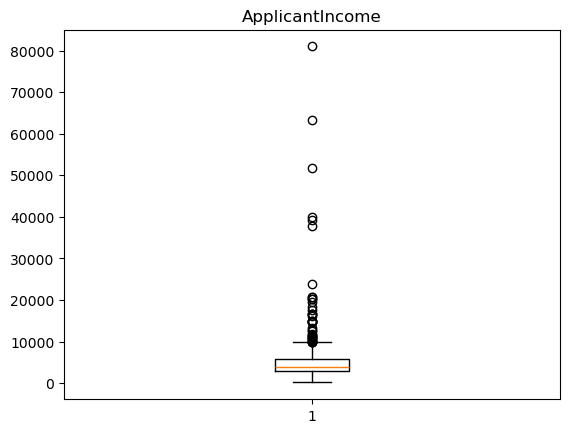

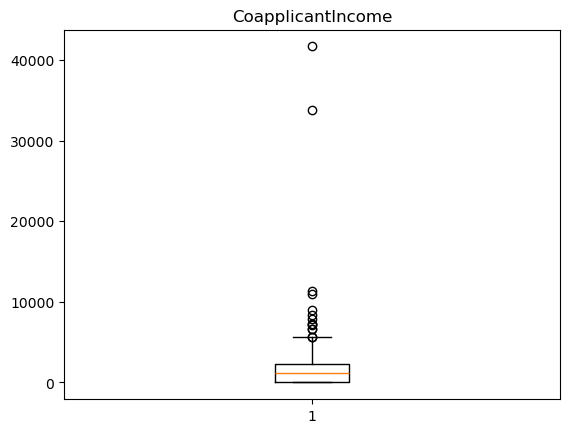

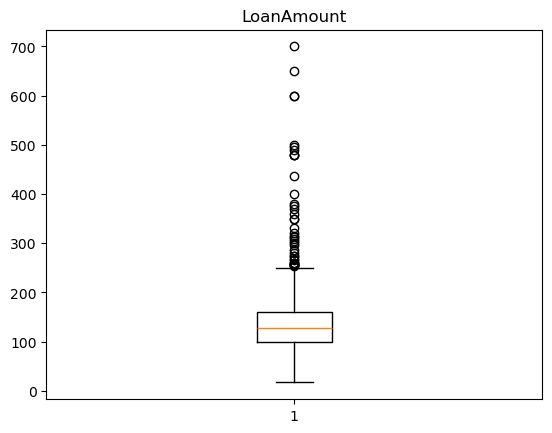

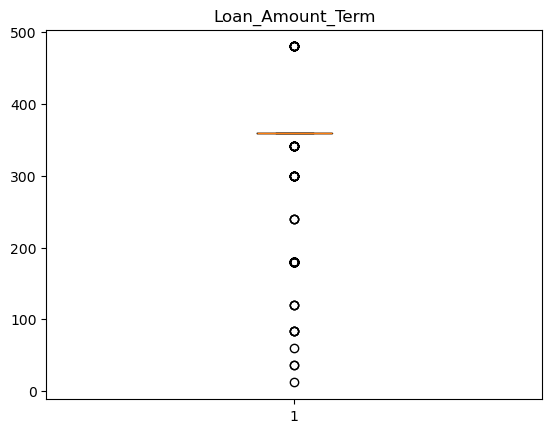

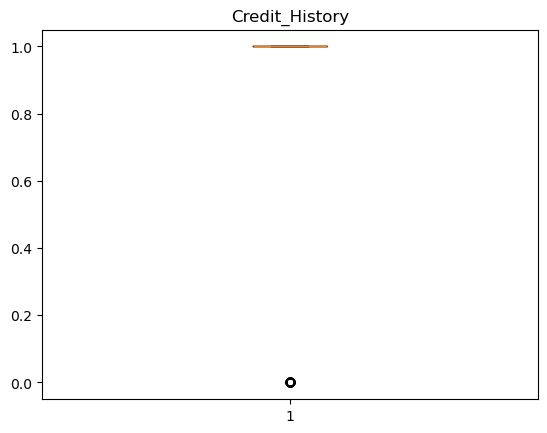

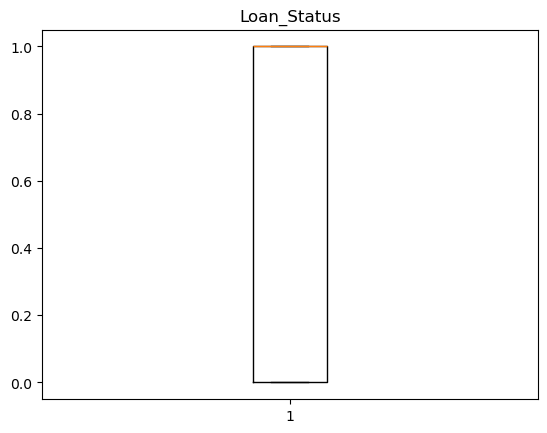

In [13]:
for i in df.columns:
    if df[i].dtype != 'object':
        plt.boxplot(df[i])
        plt.title(i)
        plt.show()

In [14]:
#Label encoding - convert categorical columns to numerical
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

In [15]:
mapping = {}
for i in df.columns:
    if df[i].dtype == 'object' and i!= 'Loan_ID':
        df[i] = le.fit_transform(df[i])
        mapping[i] = dict(zip(le.classes_,le.transform(le.classes_)))
print(mapping)

{'Gender': {'Female': np.int64(0), 'Male': np.int64(1)}, 'Married': {'No': np.int64(0), 'Yes': np.int64(1)}, 'Dependents': {'0': np.int64(0), '1': np.int64(1), '2': np.int64(2), '3+': np.int64(3)}, 'Education': {'Graduate': np.int64(0), 'Not Graduate': np.int64(1)}, 'Self_Employed': {'No': np.int64(0), 'Yes': np.int64(1)}, 'Property_Area': {'Rural': np.int64(0), 'Semiurban': np.int64(1), 'Urban': np.int64(2)}}


In [16]:
df

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP002305,0,0,0,0,0,4547,0.0,115.0,360.000000,1.0,1,1
1,LP001715,1,1,3,1,1,5703,0.0,130.0,360.000000,1.0,0,1
2,LP002086,0,1,0,0,0,4333,2451.0,110.0,360.000000,1.0,2,0
3,LP001136,1,1,0,1,1,4695,0.0,96.0,341.297071,1.0,2,1
4,LP002529,1,1,2,0,0,6700,1750.0,230.0,300.000000,1.0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
486,LP002103,1,1,1,0,1,9833,1833.0,182.0,180.000000,1.0,2,1
487,LP001790,0,0,1,0,0,3812,0.0,112.0,360.000000,1.0,0,1
488,LP001401,1,1,1,0,0,14583,0.0,185.0,180.000000,1.0,0,1
489,LP002893,1,0,0,0,0,1836,33837.0,90.0,360.000000,1.0,2,0


In [17]:
#model building
x = df.drop(columns=['Loan_ID', 'Loan_Status'])
y = df['Loan_Status']

In [18]:
x

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
0,0,0,0,0,0,4547,0.0,115.0,360.000000,1.0,1
1,1,1,3,1,1,5703,0.0,130.0,360.000000,1.0,0
2,0,1,0,0,0,4333,2451.0,110.0,360.000000,1.0,2
3,1,1,0,1,1,4695,0.0,96.0,341.297071,1.0,2
4,1,1,2,0,0,6700,1750.0,230.0,300.000000,1.0,1
...,...,...,...,...,...,...,...,...,...,...,...
486,1,1,1,0,1,9833,1833.0,182.0,180.000000,1.0,2
487,0,0,1,0,0,3812,0.0,112.0,360.000000,1.0,0
488,1,1,1,0,0,14583,0.0,185.0,180.000000,1.0,0
489,1,0,0,0,0,1836,33837.0,90.0,360.000000,1.0,2


In [19]:
y

0      1
1      1
2      0
3      1
4      1
      ..
486    1
487    1
488    1
489    0
490    1
Name: Loan_Status, Length: 491, dtype: int64

In [20]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size = 0.20,random_state = 42)
x_train

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
140,1,1,0,0,0,2058,2134.0,88.0,360.000000,1.0,2
433,1,1,3,0,0,4416,1250.0,110.0,360.000000,1.0,2
416,0,0,0,0,0,5000,0.0,132.0,360.000000,1.0,0
489,1,0,0,0,0,1836,33837.0,90.0,360.000000,1.0,2
25,0,0,0,0,0,8333,0.0,280.0,360.000000,1.0,1
...,...,...,...,...,...,...,...,...,...,...,...
106,1,1,1,0,0,9538,0.0,187.0,360.000000,1.0,2
270,1,1,0,0,0,2600,3500.0,115.0,341.297071,1.0,2
348,0,0,0,0,0,5417,0.0,143.0,480.000000,0.0,2
435,1,1,0,0,0,1025,5500.0,216.0,360.000000,1.0,0


In [21]:
x_test

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
452,1,1,0,0,0,1820,1719.0,100.0,360.0,1.0,2
84,1,1,0,0,1,2577,3750.0,152.0,360.0,1.0,0
434,1,1,3,0,0,3400,2500.0,123.0,360.0,0.0,0
474,1,0,0,0,0,4895,0.0,102.0,360.0,1.0,1
428,1,1,2,0,0,2500,1840.0,109.0,360.0,1.0,2
...,...,...,...,...,...,...,...,...,...,...,...
376,1,1,0,0,0,63337,0.0,490.0,180.0,1.0,2
56,1,1,0,0,1,3000,0.0,66.0,360.0,1.0,2
275,1,1,3,1,0,3173,0.0,74.0,360.0,1.0,1
398,1,0,0,0,0,2500,0.0,55.0,360.0,1.0,1


In [22]:
y_train

140    1
433    1
416    1
489    0
25     1
      ..
106    1
270    1
348    0
435    1
102    1
Name: Loan_Status, Length: 392, dtype: int64

In [23]:
y_test

452    1
84     1
434    0
474    1
428    1
      ..
376    1
56     1
275    1
398    1
325    0
Name: Loan_Status, Length: 99, dtype: int64

In [24]:
from sklearn.tree import DecisionTreeClassifier

In [25]:
dt_model = DecisionTreeClassifier()

In [26]:
dt_model.fit(x_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [27]:
#test the model
y_pred = dt_model.predict(x_test)
y_pred

array([1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1,
       1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1,
       1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1,
       1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1,
       1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0])

In [28]:
#Evaluating the model
from sklearn.metrics import *

In [29]:
accuracy_score(y_test,y_pred)

0.6767676767676768

In [30]:
precision_score(y_test,y_pred)

0.7796610169491526

In [31]:
recall_score(y_test,y_pred)

0.7076923076923077

In [32]:
from sklearn import tree

[Text(0.3572198275862069, 0.975, 'x[9] <= 0.5\ngini = 0.412\nsamples = 392\nvalue = [114, 278]'),
 Text(0.14224137931034483, 0.925, 'x[7] <= 547.5\ngini = 0.208\nsamples = 51\nvalue = [45, 6]'),
 Text(0.24973060344827586, 0.95, 'True  '),
 Text(0.125, 0.875, 'x[6] <= 8115.0\ngini = 0.18\nsamples = 50\nvalue = [45, 5]'),
 Text(0.07758620689655173, 0.825, 'x[6] <= 1355.0\ngini = 0.153\nsamples = 48\nvalue = [44, 4]'),
 Text(0.034482758620689655, 0.775, 'x[7] <= 129.0\ngini = 0.069\nsamples = 28\nvalue = [27, 1]'),
 Text(0.017241379310344827, 0.725, 'gini = 0.0\nsamples = 19\nvalue = [19, 0]'),
 Text(0.05172413793103448, 0.725, 'x[7] <= 133.0\ngini = 0.198\nsamples = 9\nvalue = [8, 1]'),
 Text(0.034482758620689655, 0.675, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.06896551724137931, 0.675, 'gini = 0.0\nsamples = 8\nvalue = [8, 0]'),
 Text(0.1206896551724138, 0.775, 'x[6] <= 1440.5\ngini = 0.255\nsamples = 20\nvalue = [17, 3]'),
 Text(0.10344827586206896, 0.725, 'gini = 0.0\nsampl

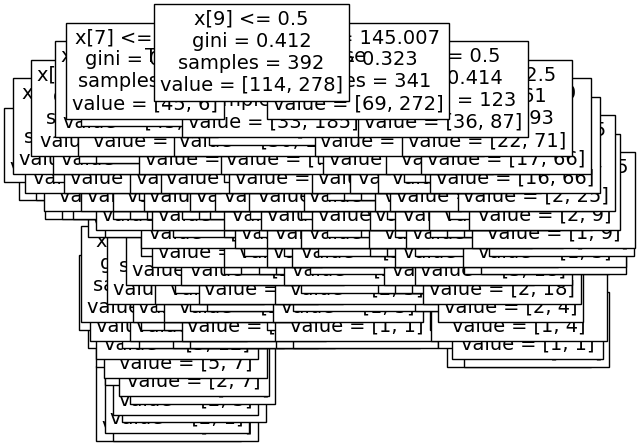

In [33]:
tree.plot_tree(dt_model, fontsize = 14)

In [34]:
dt_model.get_depth()

19

In [35]:
depths=[1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21]
for i in depths:
  dt_model=DecisionTreeClassifier(max_depth=i)
  dt_model.fit(x_train,y_train)
  y_pred=dt_model.predict(x_test)
  acc=accuracy_score(y_test,y_pred)
  print(' For Max Depth',i,'Accuracy Score is:',acc)

 For Max Depth 1 Accuracy Score is: 0.8282828282828283
 For Max Depth 2 Accuracy Score is: 0.8282828282828283
 For Max Depth 3 Accuracy Score is: 0.8282828282828283
 For Max Depth 4 Accuracy Score is: 0.8080808080808081
 For Max Depth 5 Accuracy Score is: 0.8181818181818182
 For Max Depth 6 Accuracy Score is: 0.8080808080808081
 For Max Depth 7 Accuracy Score is: 0.7777777777777778
 For Max Depth 8 Accuracy Score is: 0.7878787878787878
 For Max Depth 9 Accuracy Score is: 0.797979797979798
 For Max Depth 10 Accuracy Score is: 0.7777777777777778
 For Max Depth 11 Accuracy Score is: 0.7878787878787878
 For Max Depth 12 Accuracy Score is: 0.7474747474747475
 For Max Depth 13 Accuracy Score is: 0.696969696969697
 For Max Depth 14 Accuracy Score is: 0.7171717171717171
 For Max Depth 15 Accuracy Score is: 0.7070707070707071
 For Max Depth 16 Accuracy Score is: 0.6868686868686869
 For Max Depth 17 Accuracy Score is: 0.696969696969697
 For Max Depth 18 Accuracy Score is: 0.6666666666666666
 For

**Accuracy score is the highest for Max depth from 1 to 3**